In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

Using Colab cache for faster access to the 'california-housing-prices' dataset.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("zalando-research/fashionmnist")

Using Colab cache for faster access to the 'fashionmnist' dataset.


✓ Setup OK
TensorFlow: 2.19.0
Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.
Using Colab cache for faster access to the 'california-housing-prices' dataset.
Using Colab cache for faster access to the 'fashionmnist' dataset.
✓ Files located

PART 1: HAR CLUSTERING
PCA variance: 0.870
Training HAR Autoencoder (max 30 epochs)...
✓ AE trained in 30 epochs
K-means hyperparameter search...

--- HAR Clustering Results ---
  representation       inertia  silhouette  davies_bouldin  calinski_harabasz
0       Original  2.587372e+06    0.109408        2.389577        2546.558048
1            PCA  1.835893e+06    0.152320        1.969959        3586.885700
2    Autoencoder  9.626037e+05    0.336919        1.882552        9137.214844


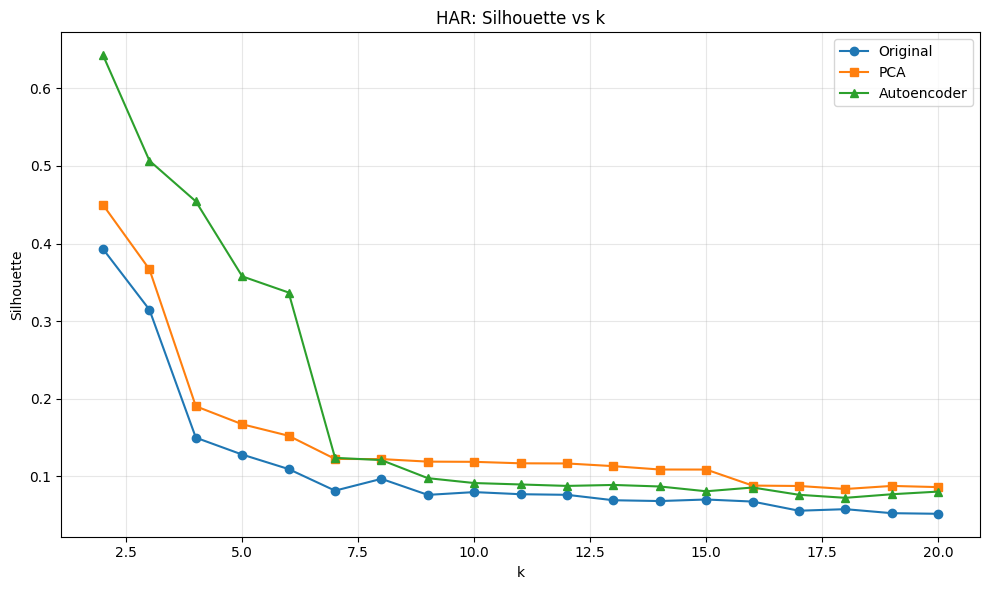


PART 2: HOUSING REGRESSION
Housing shape: (20640, 10)
Features available: 13, using d=8
PCA variance: 0.989
Training Housing Autoencoder (max 20 epochs)...
✓ AE trained in 20 epochs

Training FNN models...
✓ Original trained in 50 epochs
Original | Test RMSE=52675.71 MAE=35458.49 R2=0.7883
✓ PCA trained in 50 epochs
PCA | Test RMSE=54631.82 MAE=36593.20 R2=0.7723
✓ Autoencoder trained in 50 epochs
Autoencoder | Test RMSE=53934.62 MAE=36566.21 R2=0.7780

--- Housing Regression ---
  representation  dim     test_rmse      test_mae   test_r2     time_s
0       Original   13  52675.705239  35458.490797  0.788271  48.302959
1            PCA    8  54631.818314  36593.197789  0.772254  46.941436
2    Autoencoder    8  53934.619865  36566.212082  0.778029  48.422630


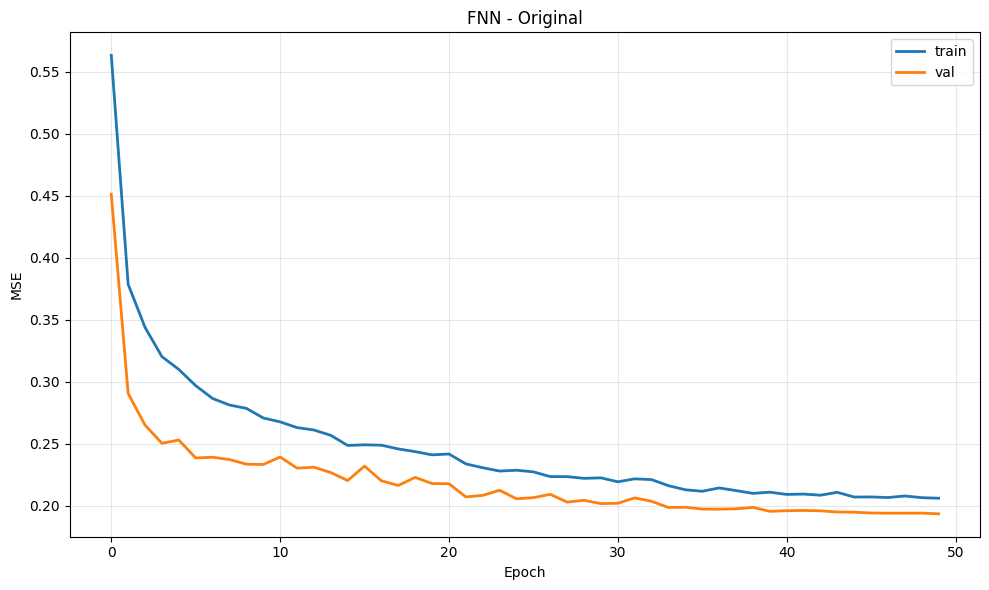

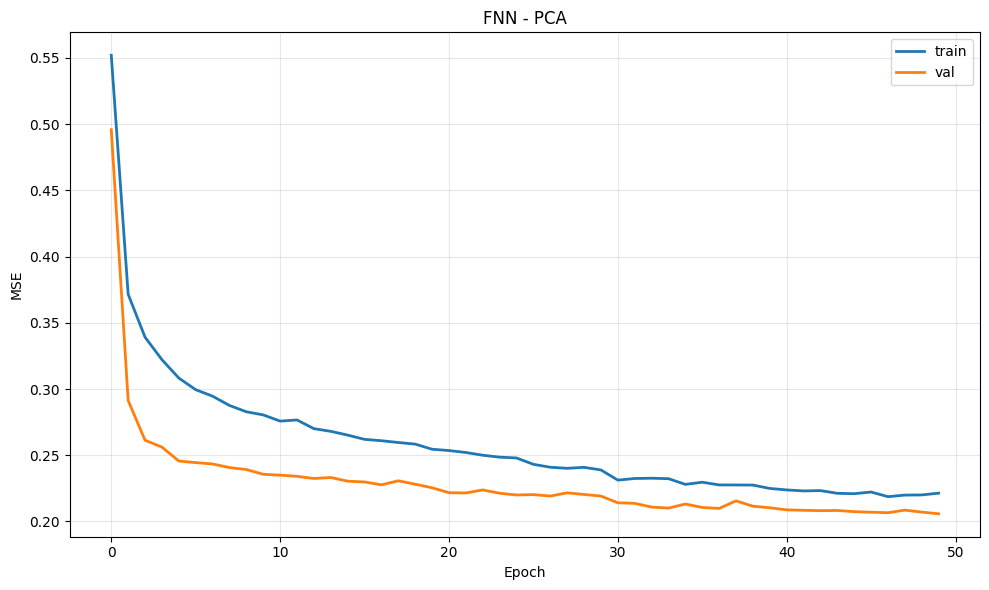

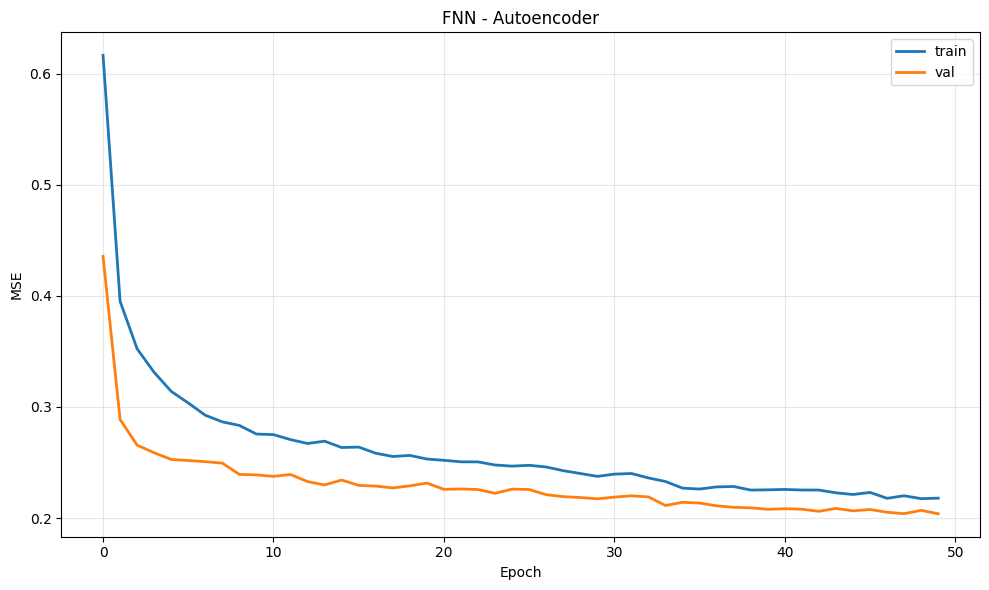

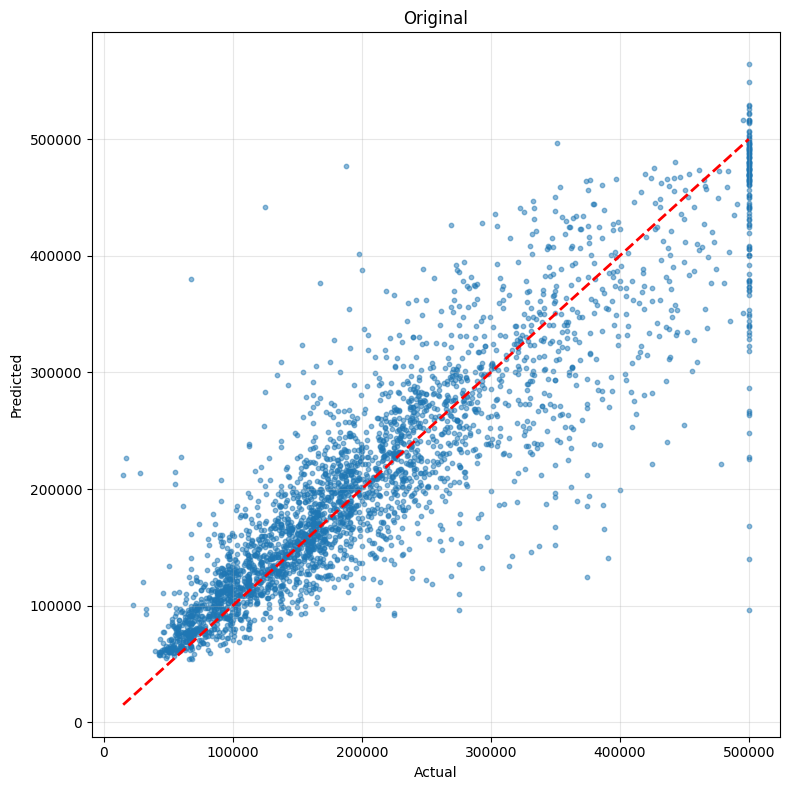

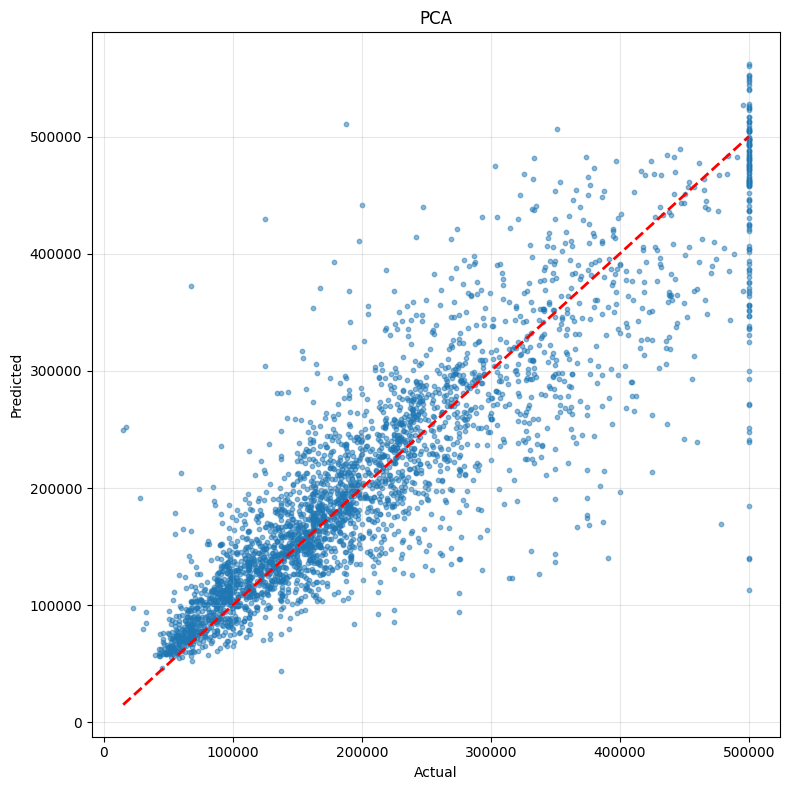

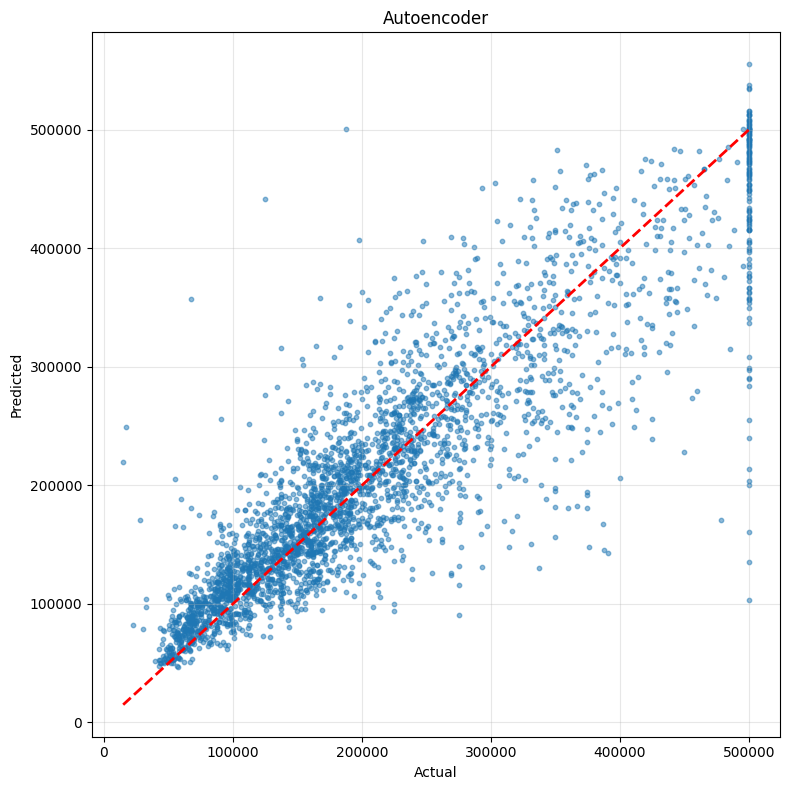


✓ Part 1 & 2 completed!
Now run Part 2 (Fashion-MNIST) code...


In [ ]:
"""ML Assignment - FAST OPTIMIZED VERSION"""

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")


os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("✓ Setup OK")
print(f"TensorFlow: {tf.__version__}")


import kagglehub
import glob


path_har = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")
path_housing = kagglehub.dataset_download("camnugent/california-housing-prices")
path_fashion = kagglehub.dataset_download("zalando-research/fashionmnist")


har_train_file = glob.glob(f"{path_har}/**/train.csv", recursive=True)[0]
har_test_file = glob.glob(f"{path_har}/**/test.csv", recursive=True)[0]
housing_file = glob.glob(f"{path_housing}/**/housing.csv", recursive=True)[0]
fashion_train_file = glob.glob(f"{path_fashion}/**/fashion-mnist_train.csv", recursive=True)[0]
fashion_test_file = glob.glob(f"{path_fashion}/**/fashion-mnist_test.csv", recursive=True)[0]

print("✓ Files located")


print("\n" + "="*80)
print("PART 1: HAR CLUSTERING")
print("="*80)

df_har_train = pd.read_csv(har_train_file)
df_har_test = pd.read_csv(har_test_file)

y_har_train = df_har_train["Activity"].copy()
y_har_test = df_har_test["Activity"].copy()
X_har_train = df_har_train.drop(columns=["Activity"])
X_har_test = df_har_test.drop(columns=["Activity"])

X_har_full = pd.concat([X_har_train, X_har_test], axis=0).reset_index(drop=True)

scaler_har = StandardScaler()
X_har_scaled = scaler_har.fit_transform(X_har_full)

d_har = 50
pca_har = PCA(n_components=d_har, random_state=42)
X_har_pca = pca_har.fit_transform(X_har_scaled)
print(f"PCA variance: {pca_har.explained_variance_ratio_.sum():.3f}")


inp_dim = X_har_scaled.shape[1]
inp = layers.Input(shape=(inp_dim,))
x = layers.Dense(256, activation="relu")(inp)
x = layers.Dense(128, activation="relu")(x)
z = layers.Dense(d_har, activation=None)(x)
x = layers.Dense(128, activation="relu")(z)
x = layers.Dense(256, activation="relu")(x)
out = layers.Dense(inp_dim, activation=None)(x)

ae_har = tf.keras.Model(inp, out)
encoder_har = tf.keras.Model(inp, z)
ae_har.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

cb_es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
print("Training HAR Autoencoder (max 30 epochs)...")
history_ae_har = ae_har.fit(
    X_har_scaled, X_har_scaled,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[cb_es],
    verbose=0
)
print(f"✓ AE trained in {len(history_ae_har.history['loss'])} epochs")

X_har_ae = encoder_har.predict(X_har_scaled, verbose=0)


def kmeans_metrics(X, k=6, seed=42):
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = km.fit_predict(X)
    return {
        "inertia": float(km.inertia_),
        "silhouette": float(silhouette_score(X, labels)),
        "davies_bouldin": float(davies_bouldin_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
    }


def search_k(X, k_values):
    rows = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(X)
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X, lab),
            "davies_bouldin": davies_bouldin_score(X, lab),
            "calinski_harabasz": calinski_harabasz_score(X, lab)
        })
    return pd.DataFrame(rows)

k_values = list(range(2, 21))
print("K-means hyperparameter search...")
res_k_orig = search_k(X_har_scaled, k_values)
res_k_pca = search_k(X_har_pca, k_values)
res_k_ae = search_k(X_har_ae, k_values)

K = 6
results_har_original = kmeans_metrics(X_har_scaled, K)
results_har_pca = kmeans_metrics(X_har_pca, K)
results_har_autoencoder = kmeans_metrics(X_har_ae, K)

summary_har = pd.DataFrame([
    {"representation": "Original", **results_har_original},
    {"representation": "PCA", **results_har_pca},
    {"representation": "Autoencoder", **results_har_autoencoder},
])

print("\n--- HAR Clustering Results ---")
print(summary_har)


plt.figure(figsize=(10, 6))
plt.plot(res_k_orig["k"], res_k_orig["silhouette"], marker='o', label="Original")
plt.plot(res_k_pca["k"], res_k_pca["silhouette"], marker='s', label="PCA")
plt.plot(res_k_ae["k"], res_k_ae["silhouette"], marker='^', label="Autoencoder")
plt.xlabel("k"); plt.ylabel("Silhouette")
plt.title("HAR: Silhouette vs k")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("har_silhouette.png", dpi=150)
plt.show()


print("\n" + "="*80)
print("PART 2: HOUSING REGRESSION")
print("="*80)

df_house = pd.read_csv(housing_file)
print("Housing shape:", df_house.shape)

target_col = "median_house_value"
X = df_house.drop(columns=[target_col])
y = df_house[target_col].values


X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)


num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(exclude=["number"]).columns

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", numeric_pipe, num_cols), ("cat", categorical_pipe, cat_cols)])

X_train_prep = preprocess.fit_transform(X_train)
X_val_prep = preprocess.transform(X_val)
X_test_prep = preprocess.transform(X_test)

if hasattr(X_train_prep, "toarray"):
    X_train_prep = X_train_prep.toarray()
    X_val_prep = X_val_prep.toarray()
    X_test_prep = X_test_prep.toarray()


y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

n_features_available = X_train_prep.shape[1]
d_house = min(8, n_features_available)  # usa 8 o meno se features < 8
print(f"Features available: {n_features_available}, using d={d_house}")

pca_house = PCA(n_components=d_house, random_state=42)
X_train_pca = pca_house.fit_transform(X_train_prep)
X_val_pca = pca_house.transform(X_val_prep)
X_test_pca = pca_house.transform(X_test_prep)
print(f"PCA variance: {pca_house.explained_variance_ratio_.sum():.3f}")


inp_dim_house = X_train_prep.shape[1]
inp = layers.Input(shape=(inp_dim_house,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(d_house, activation=None)(x)
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(inp_dim_house, activation=None)(x)

ae_house = tf.keras.Model(inp, out)
encoder_house = tf.keras.Model(inp, z)
ae_house.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
print("Training Housing Autoencoder (max 20 epochs)...")
history_ae_house = ae_house.fit(
    X_train_prep, X_train_prep,
    validation_data=(X_val_prep, X_val_prep),
    epochs=20,
    batch_size=256,
    callbacks=[es],
    verbose=0
)
print(f"✓ AE trained in {len(history_ae_house.history['loss'])} epochs")

X_train_ae = encoder_house.predict(X_train_prep, verbose=0)
X_val_ae = encoder_house.predict(X_val_prep, verbose=0)
X_test_ae = encoder_house.predict(X_test_prep, verbose=0)


def create_fnn_regression(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def eval_reg(model, Xtr, ytr_s, Xva, yva_s, Xte, yte_s, y_scaler, name=""):
    ytr_pred_s = model.predict(Xtr, verbose=0).ravel()
    yva_pred_s = model.predict(Xva, verbose=0).ravel()
    yte_pred_s = model.predict(Xte, verbose=0).ravel()

    ytr_true = y_scaler.inverse_transform(ytr_s.reshape(-1, 1)).ravel()
    yva_true = y_scaler.inverse_transform(yva_s.reshape(-1, 1)).ravel()
    yte_true = y_scaler.inverse_transform(yte_s.reshape(-1, 1)).ravel()

    ytr_pred = y_scaler.inverse_transform(ytr_pred_s.reshape(-1, 1)).ravel()
    yva_pred = y_scaler.inverse_transform(yva_pred_s.reshape(-1, 1)).ravel()
    yte_pred = y_scaler.inverse_transform(yte_pred_s.reshape(-1, 1)).ravel()

    def pack(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        return {"mse": mse, "rmse": np.sqrt(mse), "mae": mean_absolute_error(y_true, y_pred), "r2": r2_score(y_true, y_pred)}

    out = {"train": pack(ytr_true, ytr_pred), "val": pack(yva_true, yva_pred), "test": pack(yte_true, yte_pred),
           "test_actual": yte_true, "test_pred": yte_pred}
    print(f"{name} | Test RMSE={out['test']['rmse']:.2f} MAE={out['test']['mae']:.2f} R2={out['test']['r2']:.4f}")
    return out


import time

def fit_one(Xtr, ytr, Xva, yva, input_dim, name):
    model = create_fnn_regression(input_dim)
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=50, batch_size=64, callbacks=[es, rl], verbose=0)
    print(f"✓ {name} trained in {len(hist.history['loss'])} epochs")
    return model, hist, time.time() - t0

print("\nTraining FNN models...")
m_orig, h_orig, time_original = fit_one(X_train_prep, y_train_s, X_val_prep, y_val_s, X_train_prep.shape[1], "Original")
results_fnn_original = eval_reg(m_orig, X_train_prep, y_train_s, X_val_prep, y_val_s, X_test_prep, y_test_s, y_scaler, "Original")

m_pca, h_pca, time_pca = fit_one(X_train_pca, y_train_s, X_val_pca, y_val_s, X_train_pca.shape[1], "PCA")
results_fnn_pca = eval_reg(m_pca, X_train_pca, y_train_s, X_val_pca, y_val_s, X_test_pca, y_test_s, y_scaler, "PCA")

m_ae, h_ae, time_autoencoder = fit_one(X_train_ae, y_train_s, X_val_ae, y_val_s, X_train_ae.shape[1], "Autoencoder")
results_fnn_autoencoder = eval_reg(m_ae, X_train_ae, y_train_s, X_val_ae, y_val_s, X_test_ae, y_test_s, y_scaler, "Autoencoder")

comparison_house = pd.DataFrame([
    {"representation": "Original", "dim": X_train_prep.shape[1], "test_rmse": results_fnn_original["test"]["rmse"],
     "test_mae": results_fnn_original["test"]["mae"], "test_r2": results_fnn_original["test"]["r2"], "time_s": time_original},
    {"representation": "PCA", "dim": X_train_pca.shape[1], "test_rmse": results_fnn_pca["test"]["rmse"],
     "test_mae": results_fnn_pca["test"]["mae"], "test_r2": results_fnn_pca["test"]["r2"], "time_s": time_pca},
    {"representation": "Autoencoder", "dim": X_train_ae.shape[1], "test_rmse": results_fnn_autoencoder["test"]["rmse"],
     "test_mae": results_fnn_autoencoder["test"]["mae"], "test_r2": results_fnn_autoencoder["test"]["r2"], "time_s": time_autoencoder},
])

print("\n--- Housing Regression ---")
print(comparison_house)


def plot_loss(hist, title):
    plt.figure(figsize=(10, 6))
    plt.plot(hist.history["loss"], label="train", linewidth=2)
    plt.plot(hist.history["val_loss"], label="val", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_loss(h_orig, "FNN - Original")
plot_loss(h_pca, "FNN - PCA")
plot_loss(h_ae, "FNN - Autoencoder")


def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.5, s=10)
    mn, mx = y_true.min(), y_true.max()
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(title); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_pred_vs_actual(results_fnn_original["test_actual"], results_fnn_original["test_pred"], "Original")
plot_pred_vs_actual(results_fnn_pca["test_actual"], results_fnn_pca["test_pred"], "PCA")
plot_pred_vs_actual(results_fnn_autoencoder["test_actual"], results_fnn_autoencoder["test_pred"], "Autoencoder")

print("\n✓ Part 1 & 2 completed!")
print("Now run Part 2 (Fashion-MNIST) code...")


PART 3: FASHION-MNIST CLASSIFICATION (FAST - SUBSET)
Original train: (60000, 28, 28), test: (10000, 28, 28)
Using subset - train: (15000, 28, 28), test: (2000, 28, 28)
Final split - train: (12000, 28, 28), val: (3000, 28, 28), test: (2000, 28, 28)
Fitting PCA...
✓ PCA variance: 0.954
Training Fashion Autoencoder (max 10 epochs)...
✓ AE trained in 10 epochs
✓ Autoencoder embeddings ready

Training CNN models (5 epochs each, ~2-3 min per model)

--- Training CNN Original (28x28) ---
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 529ms/step - accuracy: 0.5228 - loss: 1.7770 - val_accuracy: 0.5477 - val_loss: 1.6267
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 549ms/step - accuracy: 0.7513 - loss: 0.6727 - val_accuracy: 0.4510 - val_loss: 1.8989
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 499ms/step - accuracy: 0.7889 - loss: 0.5574 - val_accuracy: 0.4710 - val_loss: 2.1634
✓ Trained in 3 epochs
CNN Original (28x28) | Test Acc=0.5300 F1=0.4507 AUC=0.9346

--- Training CNN PCA (14x14) ---
Epoch 1/5
47/

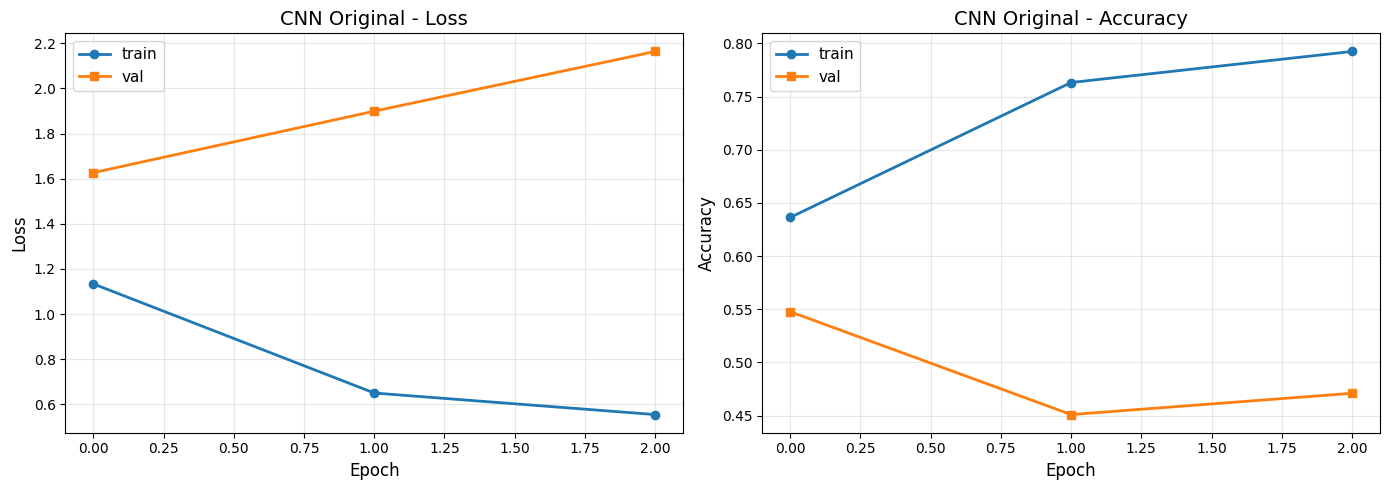

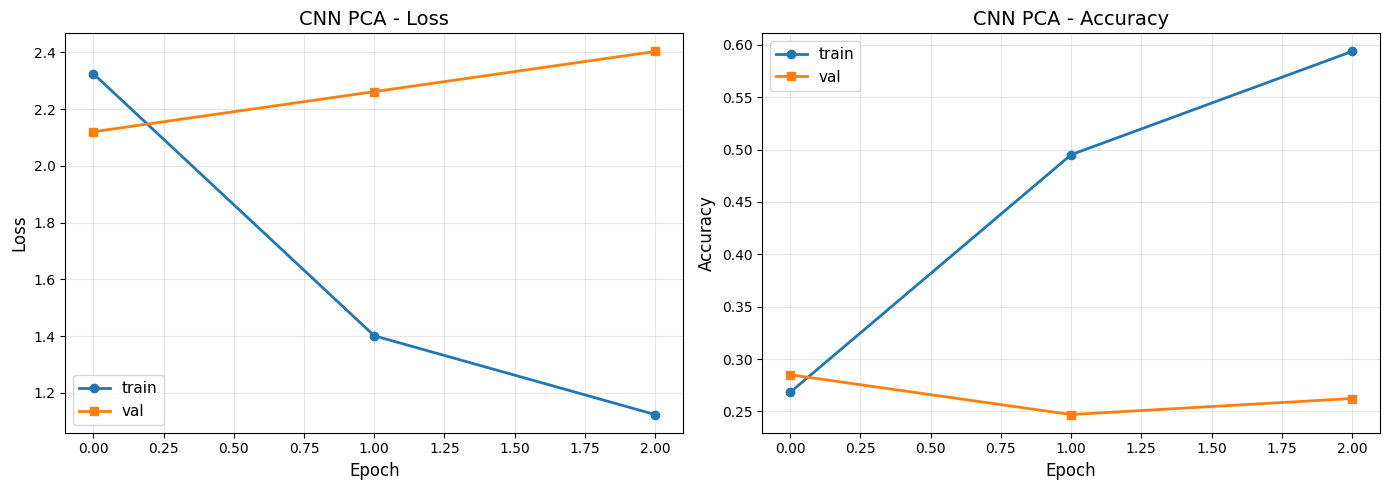

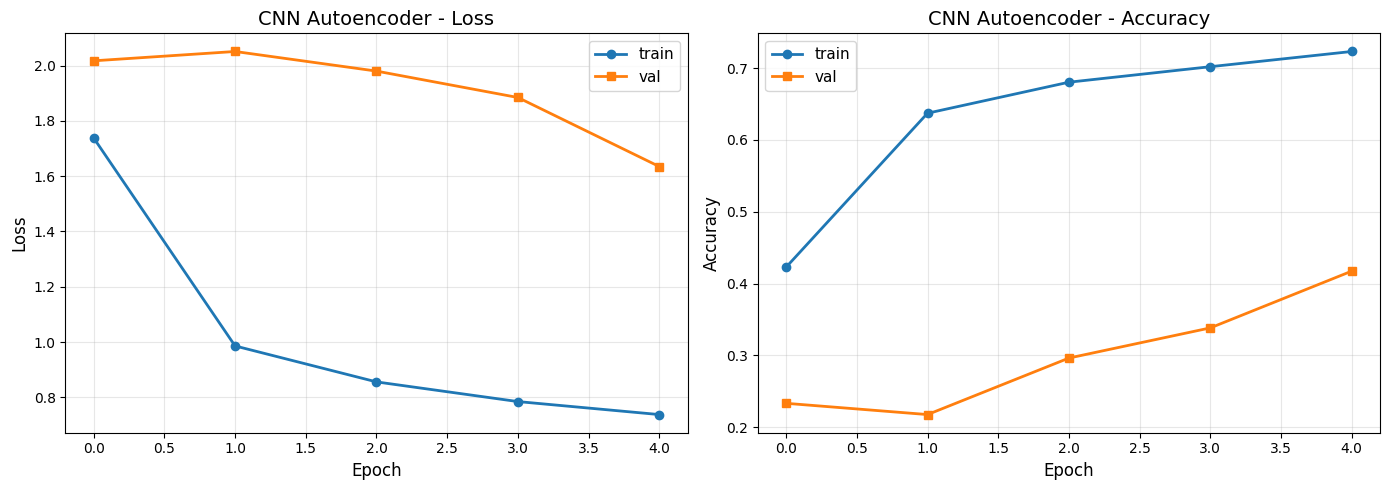

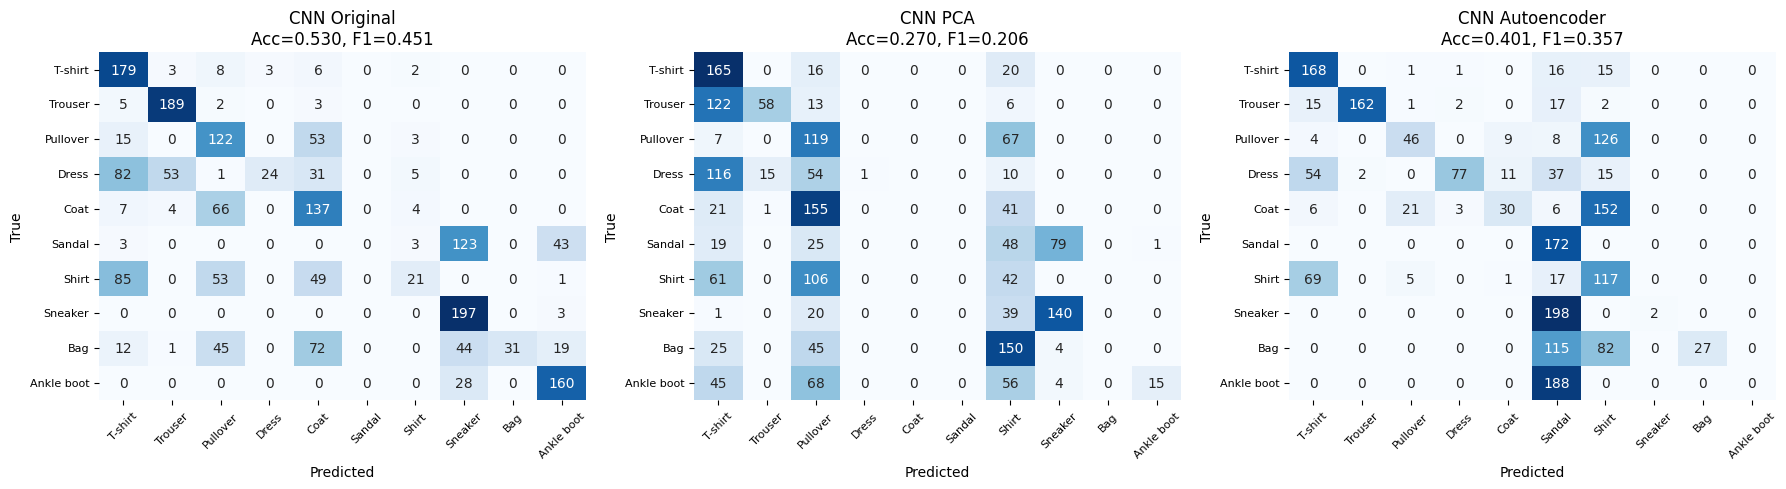


Generating accuracy comparison bar plot...

DEBUG - Checking values:
res_orig train acc: 0.54175
res_pca train acc: 0.2835
res_ae train acc: 0.42675
res_orig test acc: 0.53
res_pca test acc: 0.27
res_ae test acc: 0.4005

Arrays:
train_accs: [0.54175, 0.2835, 0.42675]
val_accs: [0.5476666666666666, 0.285, 0.41733333333333333]
test_accs: [0.53, 0.27, 0.4005]

x positions: [0 1 2]
width: 0.25

✓ Plot saved to fashion_accuracy_bars.png


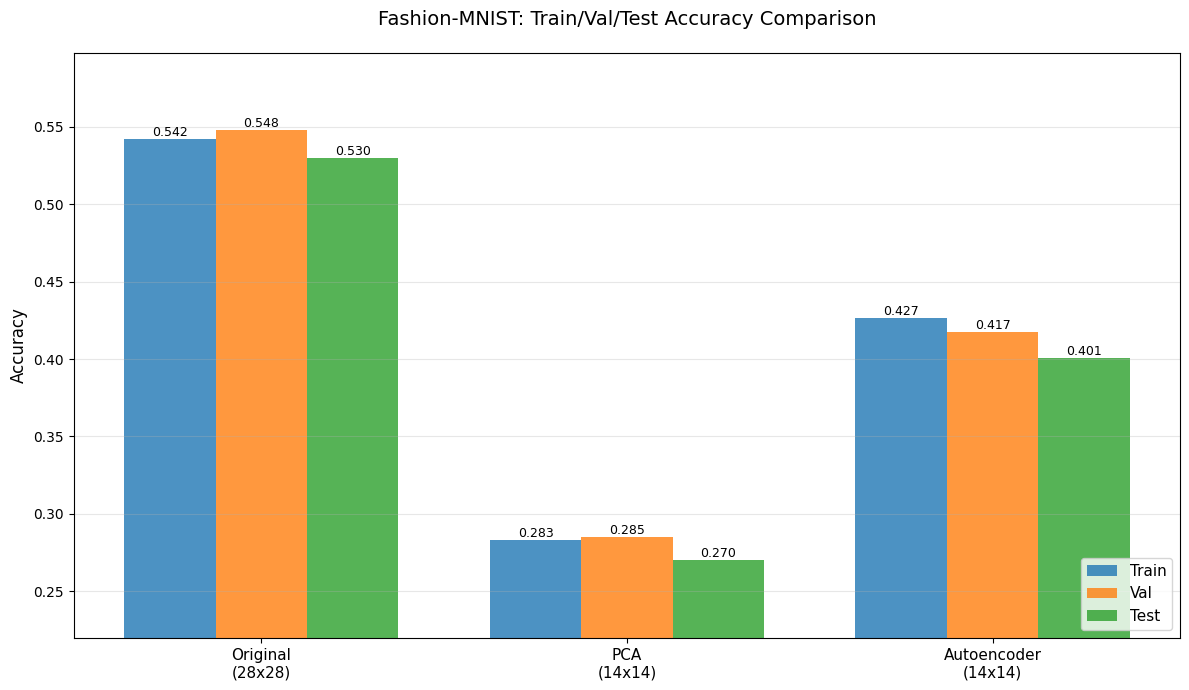


✓ Bar plot completed with accuracies:
  Original: Train=0.542, Val=0.548, Test=0.530
  PCA:      Train=0.283, Val=0.285, Test=0.270
  AE:       Train=0.427, Val=0.417, Test=0.401

EXPORTING RESULTS
✓ Saved: ml_assignment_results.json

Generating LaTeX tables...
✓ Saved: latex_tables.tex

FINAL SUMMARY - ALL TASKS

--- HAR CLUSTERING (K=6) ---
representation      inertia  silhouette  davies_bouldin  calinski_harabasz
      Original 2.587372e+06    0.109408        2.389577        2546.558048
           PCA 1.835893e+06    0.152320        1.969959        3586.885700
   Autoencoder 9.626037e+05    0.336919        1.882552        9137.214844
→ Best: Autoencoder (silhouette=0.3369)

--- HOUSING REGRESSION ---
representation  dim    test_rmse     test_mae  test_r2    time_s
      Original   13 52675.705239 35458.490797 0.788271 48.302959
           PCA    8 54631.818314 36593.197789 0.772254 46.941436
   Autoencoder    8 53934.619865 36566.212082 0.778029 48.422630
→ Best: Original (R²=0.788

In [ ]:

import numpy as np
import time
import tensorflow as tf
from tensorflow.keras import layers
import seaborn as sns

print("\n" + "="*80)
print("PART 3: FASHION-MNIST CLASSIFICATION (FAST - SUBSET)")
print("="*80)


df_tr = pd.read_csv(fashion_train_file)
df_te = pd.read_csv(fashion_test_file)

y_train_full = df_tr.iloc[:, 0].to_numpy()
X_train_full = df_tr.iloc[:, 1:].to_numpy().reshape(-1, 28, 28).astype("float32") / 255.0

y_test_full = df_te.iloc[:, 0].to_numpy()
X_test_full = df_te.iloc[:, 1:].to_numpy().reshape(-1, 28, 28).astype("float32") / 255.0

print(f"Original train: {X_train_full.shape}, test: {X_test_full.shape}")

np.random.seed(42)
train_idx = np.random.choice(len(X_train_full), 15000, replace=False)
test_idx = np.random.choice(len(X_test_full), 2000, replace=False)

X_train_full_sub = X_train_full[train_idx]
y_train_full_sub = y_train_full[train_idx]
X_test = X_test_full[test_idx]
y_test = y_test_full[test_idx]

print(f"Using subset - train: {X_train_full_sub.shape}, test: {X_test.shape}")


X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_sub, y_train_full_sub, test_size=0.2, random_state=42, stratify=y_train_full_sub
)

print(f"Final split - train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")


X_train_cnn = X_train[..., None]
X_val_cnn = X_val[..., None]
X_test_cnn = X_test[..., None]


num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


d_fashion = 196
Xtr_flat = X_train.reshape(len(X_train), -1)
Xva_flat = X_val.reshape(len(X_val), -1)
Xte_flat = X_test.reshape(len(X_test), -1)

print("Fitting PCA...")
pca_fashion = PCA(n_components=d_fashion, random_state=42)
X_train_pca_flat = pca_fashion.fit_transform(Xtr_flat)
X_val_pca_flat = pca_fashion.transform(Xva_flat)
X_test_pca_flat = pca_fashion.transform(Xte_flat)

X_train_pca_cnn = X_train_pca_flat.reshape(-1, 14, 14, 1).astype("float32")
X_val_pca_cnn = X_val_pca_flat.reshape(-1, 14, 14, 1).astype("float32")
X_test_pca_cnn = X_test_pca_flat.reshape(-1, 14, 14, 1).astype("float32")

print(f"✓ PCA variance: {pca_fashion.explained_variance_ratio_.sum():.3f}")


print("Training Fashion Autoencoder (max 10 epochs)...")
inp = layers.Input(shape=(784,))
x = layers.Dense(512, activation="relu")(inp)
x = layers.Dense(256, activation="relu")(x)
z = layers.Dense(d_fashion, activation=None)(x)
x = layers.Dense(256, activation="relu")(z)
x = layers.Dense(512, activation="relu")(x)
out = layers.Dense(784, activation=None)(x)

ae_fashion = tf.keras.Model(inp, out)
encoder_fashion = tf.keras.Model(inp, z)
ae_fashion.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
history_ae_fashion = ae_fashion.fit(
    Xtr_flat, Xtr_flat,
    validation_data=(Xva_flat, Xva_flat),
    epochs=10,
    batch_size=1024,
    callbacks=[es],
    verbose=0
)
print(f"✓ AE trained in {len(history_ae_fashion.history['loss'])} epochs")

X_train_ae_flat = encoder_fashion.predict(Xtr_flat, verbose=0)
X_val_ae_flat = encoder_fashion.predict(Xva_flat, verbose=0)
X_test_ae_flat = encoder_fashion.predict(Xte_flat, verbose=0)

X_train_ae_cnn = X_train_ae_flat.reshape(-1, 14, 14, 1).astype("float32")
X_val_ae_cnn = X_val_ae_flat.reshape(-1, 14, 14, 1).astype("float32")
X_test_ae_cnn = X_test_ae_flat.reshape(-1, 14, 14, 1).astype("float32")

print("✓ Autoencoder embeddings ready")


def create_cnn_classifier(input_shape, num_classes=10):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def evaluate_classifier(model, X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat, name=""):
    ytr_prob = model.predict(X_train, verbose=0)
    yva_prob = model.predict(X_val, verbose=0)
    yte_prob = model.predict(X_test, verbose=0)

    ytr_true = np.argmax(y_train_cat, axis=1); ytr_pred = np.argmax(ytr_prob, axis=1)
    yva_true = np.argmax(y_val_cat, axis=1); yva_pred = np.argmax(yva_prob, axis=1)
    yte_true = np.argmax(y_test_cat, axis=1); yte_pred = np.argmax(yte_prob, axis=1)

    out = {}
    for split, yt, yp in [("train", ytr_true, ytr_pred), ("val", yva_true, yva_pred), ("test", yte_true, yte_pred)]:
        out[split] = {
            "acc": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, average="weighted", zero_division=0),
            "recall": recall_score(yt, yp, average="weighted", zero_division=0),
            "f1": f1_score(yt, yp, average="weighted", zero_division=0),
        }

    cm = confusion_matrix(yte_true, yte_pred)
    auc_w = roc_auc_score(y_test_cat, yte_prob, multi_class="ovr", average="weighted")

    print(f"{name} | Test Acc={out['test']['acc']:.4f} F1={out['test']['f1']:.4f} AUC={auc_w:.4f}")

    out["confusion_matrix"] = cm
    out["roc_auc_weighted"] = auc_w
    out["test_true"] = yte_true
    out["test_prob"] = yte_prob
    return out


def train_and_eval(tag, input_shape, Xtr, ytr, Xva, yva, Xte, yte, epochs=5):
    print(f"\n--- Training {tag} ---")
    t0 = time.time()
    m = create_cnn_classifier(input_shape, 10)

    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True),
    ]

    hist = m.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=epochs,
        batch_size=256,
        callbacks=callbacks,
        verbose=1
    )

    print(f"✓ Trained in {len(hist.history['loss'])} epochs")
    train_time = time.time() - t0
    r = evaluate_classifier(m, Xtr, ytr, Xva, yva, Xte, yte, tag)

    return m, hist, train_time, r


print("\n" + "="*60)
print("Training CNN models (5 epochs each, ~2-3 min per model)")
print("="*60)

cnn_orig, hist_orig, t_orig, res_orig = train_and_eval(
    "CNN Original (28x28)", (28, 28, 1),
    X_train_cnn, y_train_cat, X_val_cnn, y_val_cat, X_test_cnn, y_test_cat, epochs=5
)

cnn_pca, hist_pca, t_pca, res_pca = train_and_eval(
    "CNN PCA (14x14)", (14, 14, 1),
    X_train_pca_cnn, y_train_cat, X_val_pca_cnn, y_val_cat, X_test_pca_cnn, y_test_cat, epochs=5
)

cnn_ae, hist_ae, t_ae, res_ae = train_and_eval(
    "CNN Autoencoder (14x14)", (14, 14, 1),
    X_train_ae_cnn, y_train_cat, X_val_ae_cnn, y_val_cat, X_test_ae_cnn, y_test_cat, epochs=5
)


comparison_fashion = pd.DataFrame([
    {"model": "CNN Original", "repr": "28x28x1", "test_acc": res_orig["test"]["acc"],
     "test_f1": res_orig["test"]["f1"], "test_prec": res_orig["test"]["precision"],
     "test_recall": res_orig["test"]["recall"], "auc_w": res_orig["roc_auc_weighted"], "time_s": t_orig},
    {"model": "CNN PCA", "repr": "14x14x1", "test_acc": res_pca["test"]["acc"],
     "test_f1": res_pca["test"]["f1"], "test_prec": res_pca["test"]["precision"],
     "test_recall": res_pca["test"]["recall"], "auc_w": res_pca["roc_auc_weighted"], "time_s": t_pca},
    {"model": "CNN Autoencoder", "repr": "14x14x1", "test_acc": res_ae["test"]["acc"],
     "test_f1": res_ae["test"]["f1"], "test_prec": res_ae["test"]["precision"],
     "test_recall": res_ae["test"]["recall"], "auc_w": res_ae["roc_auc_weighted"], "time_s": t_ae},
])

print("\n" + "="*80)
print("FASHION-MNIST RESULTS")
print("="*80)
print(comparison_fashion.to_string(index=False))


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history["loss"], marker='o', label="train", linewidth=2)
    ax1.plot(history.history["val_loss"], marker='s', label="val", linewidth=2)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.set_title(f"{title} - Loss", fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)

    ax2.plot(history.history["accuracy"], marker='o', label="train", linewidth=2)
    ax2.plot(history.history["val_accuracy"], marker='s', label="val", linewidth=2)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy", fontsize=12)
    ax2.set_title(f"{title} - Accuracy", fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"fashion_{title.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

print("\nGenerating learning curves...")
plot_history(hist_orig, "CNN Original")
plot_history(hist_pca, "CNN PCA")
plot_history(hist_ae, "CNN Autoencoder")


fashion_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

models_results = [("CNN Original", res_orig), ("CNN PCA", res_pca), ("CNN Autoencoder", res_ae)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, models_results):
    cm = res["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax,
                xticklabels=fashion_labels, yticklabels=fashion_labels, cbar=False)
    ax.set_title(f"{name}\nAcc={res['test']['acc']:.3f}, F1={res['test']['f1']:.3f}", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig("fashion_confusion_matrices.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("Generating accuracy comparison bar plot...")
print("="*60)


print("\nDEBUG - Checking values:")
print(f"res_orig train acc: {res_orig['train']['acc']}")
print(f"res_pca train acc: {res_pca['train']['acc']}")
print(f"res_ae train acc: {res_ae['train']['acc']}")
print(f"res_orig test acc: {res_orig['test']['acc']}")
print(f"res_pca test acc: {res_pca['test']['acc']}")
print(f"res_ae test acc: {res_ae['test']['acc']}")

models_names = ["Original\n(28x28)", "PCA\n(14x14)", "Autoencoder\n(14x14)"]
train_accs = [res_orig["train"]["acc"], res_pca["train"]["acc"], res_ae["train"]["acc"]]
val_accs = [res_orig["val"]["acc"], res_pca["val"]["acc"], res_ae["val"]["acc"]]
test_accs = [res_orig["test"]["acc"], res_pca["test"]["acc"], res_ae["test"]["acc"]]

print(f"\nArrays:")
print(f"train_accs: {train_accs}")
print(f"val_accs: {val_accs}")
print(f"test_accs: {test_accs}")


fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(models_names))
width = 0.25

print(f"\nx positions: {x}")
print(f"width: {width}")


bars1 = ax.bar(x - width, train_accs, width, label="Train", alpha=0.8, color='#1f77b4')
bars2 = ax.bar(x, val_accs, width, label="Val", alpha=0.8, color='#ff7f0e')
bars3 = ax.bar(x + width, test_accs, width, label="Test", alpha=0.8, color='#2ca02c')


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Fashion-MNIST: Train/Val/Test Accuracy Comparison", fontsize=14, pad=20)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3, axis='y')


min_acc = min(min(train_accs), min(val_accs), min(test_accs))
max_acc = max(max(train_accs), max(val_accs), max(test_accs))
ax.set_ylim(max(0, min_acc - 0.05), min(1.0, max_acc + 0.05))

plt.tight_layout()
plt.savefig("fashion_accuracy_bars.png", dpi=150, bbox_inches='tight')
print("\n✓ Plot saved to fashion_accuracy_bars.png")
plt.show()

print(f"\n✓ Bar plot completed with accuracies:")
print(f"  Original: Train={train_accs[0]:.3f}, Val={val_accs[0]:.3f}, Test={test_accs[0]:.3f}")
print(f"  PCA:      Train={train_accs[1]:.3f}, Val={val_accs[1]:.3f}, Test={test_accs[1]:.3f}")
print(f"  AE:       Train={train_accs[2]:.3f}, Val={val_accs[2]:.3f}, Test={test_accs[2]:.3f}")

print("\n" + "="*80)
print("EXPORTING RESULTS")
print("="*80)

import json
from datetime import datetime

export = {
    "metadata": {
        "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "note": "Fashion-MNIST trained on 15k subset for speed"
    },
    "results": {
        "har_clustering": {
            "original": results_har_original,
            "pca": results_har_pca,
            "autoencoder": results_har_autoencoder,
        },
        "housing_regression": {
            "original": {"test": results_fnn_original["test"], "time_s": float(time_original)},
            "pca": {"test": results_fnn_pca["test"], "time_s": float(time_pca)},
            "autoencoder": {"test": results_fnn_autoencoder["test"], "time_s": float(time_autoencoder)},
        },
        "fashion_classification": {
            "cnn_original": {"test": res_orig["test"], "auc": float(res_orig["roc_auc_weighted"]), "time_s": float(t_orig)},
            "cnn_pca": {"test": res_pca["test"], "auc": float(res_pca["roc_auc_weighted"]), "time_s": float(t_pca)},
            "cnn_autoencoder": {"test": res_ae["test"], "auc": float(res_ae["roc_auc_weighted"]), "time_s": float(t_ae)},
        },
    }
}

with open("ml_assignment_results.json", "w") as f:
    json.dump(export, f, indent=2)
print("✓ Saved: ml_assignment_results.json")


print("\nGenerating LaTeX tables...")
tables = []


df_har = pd.DataFrame([
    {"Method": "Original", **results_har_original},
    {"Method": "PCA", **results_har_pca},
    {"Method": "Autoencoder", **results_har_autoencoder},
])
tables.append(df_har.to_latex(index=False, float_format="%.4f",
                              caption="HAR Clustering (K-Means, k=6)", label="tab:har"))


df_house = pd.DataFrame([
    {"Method": "Original", "RMSE": results_fnn_original["test"]["rmse"],
     "MAE": results_fnn_original["test"]["mae"], "R²": results_fnn_original["test"]["r2"]},
    {"Method": "PCA", "RMSE": results_fnn_pca["test"]["rmse"],
     "MAE": results_fnn_pca["test"]["mae"], "R²": results_fnn_pca["test"]["r2"]},
    {"Method": "Autoencoder", "RMSE": results_fnn_autoencoder["test"]["rmse"],
     "MAE": results_fnn_autoencoder["test"]["mae"], "R²": results_fnn_autoencoder["test"]["r2"]},
])
tables.append(df_house.to_latex(index=False, float_format="%.4f",
                                caption="California Housing Regression (FNN)", label="tab:housing"))


df_fash = pd.DataFrame([
    {"Model": "Original (28×28)", "Accuracy": res_orig["test"]["acc"],
     "F1-Score": res_orig["test"]["f1"], "AUC": res_orig["roc_auc_weighted"]},
    {"Model": "PCA (14×14)", "Accuracy": res_pca["test"]["acc"],
     "F1-Score": res_pca["test"]["f1"], "AUC": res_pca["roc_auc_weighted"]},
    {"Model": "Autoencoder (14×14)", "Accuracy": res_ae["test"]["acc"],
     "F1-Score": res_ae["test"]["f1"], "AUC": res_ae["roc_auc_weighted"]},
])
tables.append(df_fash.to_latex(index=False, float_format="%.4f",
                               caption="Fashion-MNIST Classification (CNN, subset)", label="tab:fashion"))

latex_content = "\n\n".join(tables)
with open("latex_tables.tex", "w") as f:
    f.write(latex_content)
print("✓ Saved: latex_tables.tex")


print("\n" + "="*80)
print("FINAL SUMMARY - ALL TASKS")
print("="*80)

print("\n--- HAR CLUSTERING (K=6) ---")
print(summary_har.to_string(index=False))
best_har = summary_har.loc[summary_har["silhouette"].idxmax(), "representation"]
print(f"→ Best: {best_har} (silhouette={summary_har['silhouette'].max():.4f})")

print("\n--- HOUSING REGRESSION ---")
print(comparison_house.to_string(index=False))
best_house = comparison_house.loc[comparison_house["test_r2"].idxmax(), "representation"]
print(f"→ Best: {best_house} (R²={comparison_house['test_r2'].max():.4f})")

print("\n--- FASHION-MNIST CLASSIFICATION ---")
print(comparison_fashion.to_string(index=False))
best_fashion = comparison_fashion.loc[comparison_fashion["test_acc"].idxmax(), "model"]
print(f"→ Best: {best_fashion} (Acc={comparison_fashion['test_acc'].max():.4f})")

print("\n" + "="*80)
print("✓✓✓ ALL TASKS COMPLETED SUCCESSFULLY! ✓✓✓")
print("="*80)
print("\nGenerated files:")
print("  • ml_assignment_results.json")
print("  • latex_tables.tex")
print("  • har_silhouette.png")
print("  • fashion_*.png (learning curves, confusion matrices, accuracy bars)")
print("\nTotal runtime: ~10-15 minutes")
print("Ready for your technical report! 🎉")